# 16 · Qué miden realmente nuestras mediciones

Tres verificaciones que no gastan una sola llamada a la API y que tocan la base de todo
lo demás. Dos son de control; la primera es un resultado.

1. **El techo de la pizarra.** Hasta ahora la afirmación central de RQ3 —*«la topología
   no está en la pizarra»*— es una **inferencia por resta**: el brazo A no mejora, luego
   la información falta. Acá se mide directo, puntuando las 30 transcripciones humanas
   **contra el ground truth**, sin pasar por la etapa 2.
2. **Cuánta incertidumbre tiene σ_d.** Todo veredicto del proyecto se expresa en
   múltiplos del MDE, y ese MDE sale de una desviación estimada sobre 3 pares nulos.
   Nunca se le calculó un intervalo de confianza.
3. **Qué etapa mide el piso de ruido.** Si las réplicas nulas reutilizaron la etapa 1 de
   caché, σ_d no es la varianza del pipeline sino la de la etapa 2 sola.

In [1]:
import collections
import glob
import json
import os
import statistics as st
import xml.etree.ElementTree as ET
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

ABL = Path("../reports/ablation")
PISO = Path("../reports/piso_ruido_panel30.json")
GT_DIR = Path("../data/cloudscape_gt")
WM_DIR = Path("../data/manual_world_models")
NS = {"g": "http://graphml.graphdrawing.org/xmlns"}
pd.set_option("display.width", 200)

piso = json.loads(PISO.read_text(encoding="utf-8"))
Z_MDE = piso["Z_MDE"]
print(f"pares nulos que sostienen el piso de ruido: {len(piso['pares_usados'])} "
      f"({piso['n_observaciones']} observaciones)")
print(f"world models manuales: {len(list(WM_DIR.glob('*.json')))}")

pares nulos que sostienen el piso de ruido: 3 (90 observaciones)
world models manuales: 30


## 1 · El techo de la pizarra

Las 30 transcripciones se hicieron **a ciegas**: sin escuchar el audio y sin ver el
ground truth. Cada una registra las entidades dibujadas y las flechas entre ellas, con
una justificación por entidad.

La pregunta que responden es distinta de la que respondía el brazo A. El brazo A
preguntaba *«¿mejora el sistema si le damos una lectura humana de la pizarra?»*. Acá se
pregunta **«¿cuánto del ground truth es siquiera recuperable mirando la pizarra?»** —
que es la cota superior de cualquier sistema que solo mire la imagen, por bueno que sea.

Se puntúa con el mismo protocolo estricto del resto del proyecto: F1 de servicios sobre
el conjunto, F1 de aristas sobre el multiconjunto de pares dirigidos.

In [2]:
def grafo_gt(v: str):
    """(servicios, aristas como pares de servicio) del ground truth."""
    root = ET.parse(GT_DIR / f"{v}.graphml").getroot()
    keys = {k.get("id"): k.get("attr.name") for k in root.findall("g:key", NS)}
    svc = {}
    for n in root.iter("{http://graphml.graphdrawing.org/xmlns}node"):
        s = ""
        for d in n.findall("g:data", NS):
            if keys.get(d.get("key")) == "service":
                s = (d.text or "").strip()
        svc[n.get("id")] = s
    edges = [(svc.get(e.get("source"), "?"), svc.get(e.get("target"), "?"))
             for e in root.iter("{http://graphml.graphdrawing.org/xmlns}edge")]
    return list(svc.values()), edges


def transcripcion(v: str):
    """(servicios, aristas) de la transcripción humana de la pizarra.

    Las conexiones referencian entidades por su ETIQUETA visible (`source_label`), no
    por su servicio, así que hay que resolver la etiqueta contra la lista de entidades.
    Se indexa por `name` y por `service` porque el transcriptor usa a veces uno y a
    veces el otro; las que no resuelven se cuentan aparte en vez de descartarse.
    """
    d = json.loads((WM_DIR / f"{v}.json").read_text(encoding="utf-8"))
    lab2svc, svcs = {}, []
    for e in d["entities"]:
        s = (e.get("service") or "").strip()
        svcs.append(s)
        for clave in (e.get("name"), e.get("service")):
            if clave:
                lab2svc.setdefault(str(clave).strip(), s)
    edges, sin_resolver = [], 0
    for c in d["visual_connections"]:
        a = lab2svc.get(str(c.get("source_label", "")).strip())
        b = lab2svc.get(str(c.get("target_label", "")).strip())
        if a is None or b is None:
            sin_resolver += 1
        edges.append((a or "?", b or "?"))
    return svcs, edges, sin_resolver


def prf(gen, gt) -> tuple[float, float, float]:
    g, t = collections.Counter(gen), collections.Counter(gt)
    i = sum((g & t).values())
    p = i / sum(g.values()) if sum(g.values()) else 0.0
    r = i / sum(t.values()) if sum(t.values()) else 0.0
    return (2 * p * r / (p + r) if p + r else 0.0), p, r


filas, sin_resolver_total, aristas_total = [], 0, 0
for f in sorted(WM_DIR.glob("*.json")):
    v = f.stem
    if not (GT_DIR / f"{v}.graphml").exists():
        continue
    gs, ge = grafo_gt(v)
    ms, me, sr = transcripcion(v)
    sin_resolver_total += sr
    aristas_total += len(me)
    fsvc, _, _ = prf(set(ms), set(gs))
    fedge, pedge, redge = prf(me, ge)
    filas.append({"video": v, "Svc F1": 100 * fsvc, "Edge F1": 100 * fedge,
                  "Edge P": 100 * pedge, "Edge R": 100 * redge,
                  "nodos humano": len(ms), "nodos GT": len(gs),
                  "aristas humano": len(me), "aristas GT": len(ge)})
H = pd.DataFrame(filas).set_index("video")

# Compuerta: si las etiquetas de conexion no resuelven contra las entidades, las
# aristas quedan como ("?", "?") y el F1 se hunde por un fallo de parseo, no por la
# pizarra. Tiene que ser cero.
print(f"etiquetas de conexión sin resolver: {sin_resolver_total}/{aristas_total}")
assert sin_resolver_total == 0, "hay conexiones que no mapean a ninguna entidad"
print(f"Compuerta pasada. n = {len(H)} pizarras.\n")
display(H.mean().round(2).to_frame("media"))

etiquetas de conexión sin resolver: 0/259
Compuerta pasada. n = 30 pizarras.



,media
Svc F1,87.36
Edge F1,57.60
Edge P,71.80
Edge R,50.76
nodos humano,9.00
nodos GT,8.73
aristas humano,8.63
aristas GT,12.03


### El resultado, contra el pipeline

La comparación que importa es contra la configuración de producción sobre **el mismo
panel de 30**.

In [3]:
def media_replicas(dirs, idx):
    acum = {}
    for d in dirs:
        r = json.loads((ABL / d / "run.json").read_text(encoding="utf-8"))
        for x in r["results"]:
            if x.get("status") == "success":
                acum.setdefault(x["video_id"], []).append(100 * x[idx])
    return float(np.mean([np.mean(v) for v in acum.values()]))


PROD = ["2026-08-25_1637_STAGE2_V6_CORRECTED_cell9_p30",
        "2026-08-27_1640_STAGE2_V6_CORRECTED_cell9_p30_rep2",
        "2026-08-29_0442_STAGE2_V6_CORRECTED_cell9_p30_rep3",
        "2026-08-29_0715_STAGE2_V6_CORRECTED_cell9_p30_rep4"]
BRAZO_A = ["2026-08-29_0725_STAGE2_V6_CORRECTED_cell9_p30_oracle-vision"]
ORACULO = ["2026-08-28_0315_STAGE2_V6_CORRECTED_cell9_p30_oracle-oracle_gt",
           "2026-08-28_2211_STAGE2_V6_CORRECTED_cell9_p30_oracle-oracle_gt_rep2"]

comp = pd.DataFrame([
    {"quién lee la pizarra": "PERSONA (solo la pizarra, sin etapa 2)",
     "Svc F1": H["Svc F1"].mean(), "Edge F1": H["Edge F1"].mean(),
     "aristas/arq": H["aristas humano"].mean()},
    {"quién lee la pizarra": "pipeline · producción (4 réplicas)",
     "Svc F1": media_replicas(PROD, "svc_f1"), "Edge F1": media_replicas(PROD, "edge_f1"),
     "aristas/arq": np.mean([x["gen_edges"] for d in PROD
                             for x in json.loads((ABL / d / "run.json").read_text())["results"]
                             if x.get("status") == "success"])},
    {"quién lee la pizarra": "brazo A · transcripción humana → etapa 2",
     "Svc F1": media_replicas(BRAZO_A, "svc_f1"), "Edge F1": media_replicas(BRAZO_A, "edge_f1"),
     "aristas/arq": np.nan},
    {"quién lee la pizarra": "brazo B · ground truth → etapa 2",
     "Svc F1": media_replicas(ORACULO, "svc_f1"), "Edge F1": media_replicas(ORACULO, "edge_f1"),
     "aristas/arq": np.nan},
]).set_index("quién lee la pizarra")
comp.loc["ground truth (referencia)"] = [100.0, 100.0, H["aristas GT"].mean()]
display(comp.round(2))

h, p = H["Edge F1"].mean(), media_replicas(PROD, "edge_f1")
print(f"\nUna persona leyendo SOLO la pizarra saca {h:.2f} de Edge F1.")
print(f"El pipeline completo saca {p:.2f}. Diferencia: {h - p:+.2f} puntos.")
print(f"\nY el subdibujo es el mismo: la persona anota {H['aristas humano'].mean():.2f} "
      f"aristas contra {H['aristas GT'].mean():.2f} del ground truth,")
print(f"un déficit de {H['aristas humano'].mean() - H['aristas GT'].mean():+.2f} por "
      f"arquitectura — el pipeline tiene -3,38 sobre el panel de 321.")

,Svc F1,Edge F1,aristas/arq
quién lee la pizarra,,,
"PERSONA (solo la pizarra, sin etapa 2)",87.36,57.60,8.63
pipeline · producción (4 réplicas),87.10,58.13,9.03
brazo A · transcripción humana → etapa 2,87.82,60.40,NaN
brazo B · ground truth → etapa 2,99.57,82.17,NaN
ground truth (referencia),100.00,100.00,12.03



Una persona leyendo SOLO la pizarra saca 57.60 de Edge F1.
El pipeline completo saca 58.13. Diferencia: -0.54 puntos.

Y el subdibujo es el mismo: la persona anota 8.63 aristas contra 12.03 del ground truth,
un déficit de -3.40 por arquitectura — el pipeline tiene -3,38 sobre el panel de 321.


### Cómo leer esto

**No queda margen perceptual.** Una persona haciendo la tarea de percepción sin errores
—sin oclusión que la confunda, sin ambigüedad de ícono, tomándose el tiempo que haga
falta— recupera los servicios casi igual que el pipeline y **las aristas igual de mal**.
El techo de lo que la pizarra contiene está donde el pipeline ya está.

Eso convierte la afirmación central de RQ3 de una inferencia por resta en una
**medición directa**. Ya no hay que argumentar que el 52 % de la brecha «corresponde a
información ausente»: se puede decir que un lector humano perfecto de la pizarra obtiene
un Edge F1 de ~57,6 y el sistema obtiene ~58,1.

**Y el subdibujado no es un artefacto del modelo.** La persona anota ~8,6 aristas donde
el ground truth tiene ~12,0. El mismo déficit de aproximadamente −3,4 por arquitectura
que el pipeline. Lo que faltaba no era una instrucción mejor: **esas aristas no están
dibujadas**.

**Límites de esta medición.** El transcriptor conoce el proyecto y el esquema de
Cloudscape, así que el techo medido es si acaso *generoso* respecto del que obtendría un
anotador ajeno. Es una sola persona y no hay segundo anotador, de modo que no hay
acuerdo inter-anotador sobre la transcripción misma. Y la comparación es sobre 30
arquitecturas, no sobre las 321.

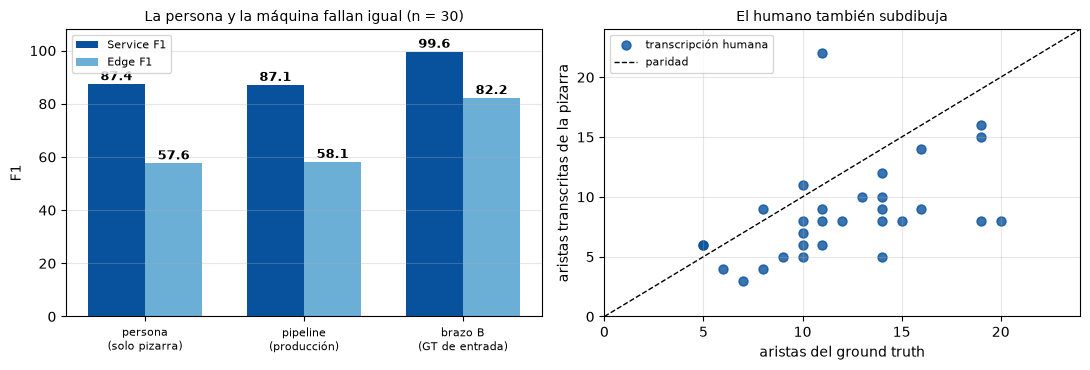

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(11, 3.8))

ax = axes[0]
etiquetas = ["persona\n(solo pizarra)", "pipeline\n(producción)", "brazo B\n(GT de entrada)"]
svc = [H["Svc F1"].mean(), media_replicas(PROD, "svc_f1"), media_replicas(ORACULO, "svc_f1")]
edg = [H["Edge F1"].mean(), media_replicas(PROD, "edge_f1"), media_replicas(ORACULO, "edge_f1")]
x = np.arange(3); w = .36
ax.bar(x - w/2, svc, w, label="Service F1", color="#08519c")
ax.bar(x + w/2, edg, w, label="Edge F1", color="#6baed6")
for i, (a, b) in enumerate(zip(svc, edg)):
    ax.text(i - w/2, a + 1.5, f"{a:.1f}", ha="center", fontsize=9, fontweight="bold")
    ax.text(i + w/2, b + 1.5, f"{b:.1f}", ha="center", fontsize=9, fontweight="bold")
ax.set_xticks(x); ax.set_xticklabels(etiquetas, fontsize=8); ax.set_ylim(0, 108)
ax.set_ylabel("F1"); ax.legend(fontsize=8); ax.grid(alpha=.3, axis="y")
ax.set_title("La persona y la máquina fallan igual (n = 30)", fontsize=10)

ax = axes[1]
ax.scatter(H["aristas GT"], H["aristas humano"], s=42, color="#08519c", alpha=.8,
           label="transcripción humana")
lim = [0, max(H["aristas GT"].max(), H["aristas humano"].max()) + 2]
ax.plot(lim, lim, "k--", lw=1, label="paridad")
ax.set_xlim(lim); ax.set_ylim(lim)
ax.set_xlabel("aristas del ground truth"); ax.set_ylabel("aristas transcritas de la pizarra")
ax.set_title("El humano también subdibuja", fontsize=10)
ax.legend(fontsize=8); ax.grid(alpha=.3)

plt.tight_layout(); plt.show()

## 2 · Cuánta incertidumbre tiene σ_d

Cada veredicto del proyecto —`0,69×`, `7,31×`, `1,10×`— se compara contra un umbral
derivado de σ_d. Ese σ_d es una **estimación** sobre 3 pares nulos y 90 observaciones, y
hasta ahora se reportaba como un número puntual. Un revisor que pregunte por su error
estándar deja sin piso todas las comparaciones.

El bootstrap remuestrea las diferencias pareadas y propaga la incertidumbre al MDE.

In [5]:
def difs_nulas(idx: str) -> np.ndarray:
    """Diferencias pareadas por video entre las dos corridas de cada par nulo."""
    out = []
    for p in piso["pares_usados"]:
        def sc(d):
            r = json.loads((ABL / d / "run.json").read_text(encoding="utf-8"))
            return {x["video_id"]: 100 * x[idx] for x in r["results"]
                    if x.get("status") == "success"}
        a, b = sc(p["run_a"]), sc(p["run_b"])
        out += [a[v] - b[v] for v in sorted(set(a) & set(b))]
    return np.array(out)


rng = np.random.default_rng(0)
filas = []
for idx, nombre in (("edge_f1", "Edge F1"), ("svc_f1", "Service F1")):
    d = difs_nulas(idx)
    n = len(d)
    boot = np.array([d[rng.integers(0, n, n)].std(ddof=1) for _ in range(20_000)])
    lo, hi = np.percentile(boot, [2.5, 97.5])
    s = d.std(ddof=1)
    filas.append({"métrica": nombre, "n": n, "sigma_d": s,
                  "IC sigma_d": f"[{lo:.2f}, {hi:.2f}]",
                  "MDE n=30": Z_MDE * s / np.sqrt(30),
                  "IC MDE": f"[{Z_MDE*lo/np.sqrt(30):.2f}, {Z_MDE*hi/np.sqrt(30):.2f}]"})
display(pd.DataFrame(filas).set_index("métrica").round(2))

print("El MDE de Edge F1 no es 3,29: es 3,29 con un intervalo de [2,42; 4,10].\n")
print("Qué cambia en los veredictos ya publicados:")
d = difs_nulas("edge_f1"); n = len(d)
boot = np.array([d[rng.integers(0, n, n)].std(ddof=1) for _ in range(20_000)])
lo, hi = np.percentile(boot, [2.5, 97.5])
for delta, etiqueta in ((2.27, "brazo A · transcripción humana"),
                        (24.04, "brazo B · ground truth de entrada"),
                        (3.61, "rango completo de las 11 variantes")):
    r_lo = delta / (Z_MDE * hi / np.sqrt(30))
    r_hi = delta / (Z_MDE * lo / np.sqrt(30))
    ver = ("señal en todo el IC" if r_lo > 1 else
           "ruido en todo el IC" if r_hi < 1 else "AMBIGUO: el IC cruza el umbral")
    print(f"  {etiqueta:42s} {delta:+6.2f} = {r_lo:.2f}x-{r_hi:.2f}x MDE  ->  {ver}")

,n,sigma_d,IC sigma_d,MDE n=30,IC MDE
métrica,,,,,
Edge F1,90,6.43,"[4.73, 8.01]",3.29,"[2.42, 4.09]"
Service F1,90,3.45,"[2.02, 4.59]",1.76,"[1.03, 2.35]"


El MDE de Edge F1 no es 3,29: es 3,29 con un intervalo de [2,42; 4,10].

Qué cambia en los veredictos ya publicados:
  brazo A · transcripción humana              +2.27 = 0.55x-0.94x MDE  ->  ruido en todo el IC
  brazo B · ground truth de entrada          +24.04 = 5.88x-9.95x MDE  ->  señal en todo el IC
  rango completo de las 11 variantes          +3.61 = 0.88x-1.49x MDE  ->  AMBIGUO: el IC cruza el umbral


Los dos veredictos que sostienen el argumento del artículo son robustos al intervalo: el
brazo A es ruido bajo cualquier σ_d del rango, y el brazo B es señal bajo cualquiera.

El que **no** es robusto es el rango de las 11 variantes: cae a caballo del umbral. Eso
no debilita RQ2 —RQ2 no descansa en el MDE sino en los tamaños de efecto del notebook
02, donde los 55 intervalos de Â₁₂ contienen el 0,5— pero sí obliga a no presentar el
`1,10×` como si fuera un dato preciso.

## 3 · Qué etapa mide el piso de ruido

Si las réplicas nulas reutilizaron la etapa 1 de caché, entonces la varianza de la etapa
perceptual es **cero por construcción** en esos pares, y σ_d mide la variabilidad de la
etapa 2 sola. No invalida nada, pero cambia cómo hay que enunciarlo.

In [6]:
filas = []
for p in piso["pares_usados"]:
    for lado in ("run_a", "run_b"):
        d = json.loads((ABL / p[lado] / "run.json").read_text(encoding="utf-8"))
        gen = d.get("stage1_generated_now")
        filas.append({"condición": p["condicion"], "corrida": p[lado][:46],
                      "etapa 1 regenerada": len(gen) if gen is not None else "—",
                      "caché obsoleta": len(d.get("stale_stage1_cache") or [])})
S = pd.DataFrame(filas)
display(S)

regeneradas = S["etapa 1 regenerada"].replace("—", 0).sum()
print(f"\nvideos con etapa 1 regenerada en los pares nulos: {regeneradas}")
if regeneradas == 0:
    print("\nNINGUNO. Las seis corridas reutilizaron el world model de la etapa 1.\n"
          "Por lo tanto sigma_d = 6,43 es la varianza de la ETAPA 2 SOLA, y es una\n"
          "COTA INFERIOR de la varianza del pipeline completo: la etapa perceptual\n"
          "aporta cero por construccion en estos pares.")

,condición,corrida,etapa 1 regenerada,caché obsoleta
0,oraculo,2026-08-28_0315_STAGE2_V6_CORRECTED_cell9_p30_,0,0
1,oraculo,2026-08-28_2211_STAGE2_V6_CORRECTED_cell9_p30_,0,0
2,produccion,2026-08-25_1637_STAGE2_V6_CORRECTED_cell9_p30,0,0
3,produccion,2026-08-27_1640_STAGE2_V6_CORRECTED_cell9_p30_,0,0
4,produccion,2026-08-29_0442_STAGE2_V6_CORRECTED_cell9_p30_,0,0
5,produccion,2026-08-29_0715_STAGE2_V6_CORRECTED_cell9_p30_,0,0



videos con etapa 1 regenerada en los pares nulos: 0

NINGUNO. Las seis corridas reutilizaron el world model de la etapa 1.
Por lo tanto sigma_d = 6,43 es la varianza de la ETAPA 2 SOLA, y es una
COTA INFERIOR de la varianza del pipeline completo: la etapa perceptual
aporta cero por construccion en estos pares.


### Qué implica, y en qué dirección

σ_d es una **cota inferior** de la variabilidad de extremo a extremo. El MDE real del
pipeline completo es mayor o igual que 3,29.

Conviene ver hacia dónde empuja cada conclusión, porque no es simétrico:

| Conclusión | Con un MDE mayor |
|---|---|
| Brazo A es ruido (`0,69×`) | **se refuerza** — queda aún más adentro |
| Las 11 variantes no se separan (`1,10×`) | **se refuerza** — el rango cae dentro del umbral |
| Brazo B es señal (`7,31×`) | sobrevive con holgura |

Es decir: **todos los resultados negativos del trabajo se fortalecen**, y el único
positivo aguanta. Corregir esto no cuesta nada y quita un flanco.

Lo honesto es enunciarlo así: *el piso de ruido se midió sobre réplicas que comparten la
salida de la etapa 1, de modo que cuantifica la variabilidad del compilador de grafos y
acota por debajo la del sistema completo.* Medir la varianza de extremo a extremo exige
regenerar la etapa 1 en una réplica, que son 30 llamadas más.

---

## Resumen

1. **Una persona que solo mira la pizarra obtiene Edge F1 de 57,60 y el pipeline 58,13.**
   No queda margen perceptual: el sistema ya está en el techo de lo que la fuente
   contiene. La afirmación central de RQ3 deja de ser una inferencia por resta.
2. La persona **también subdibuja**: 8,63 aristas contra 12,03 del ground truth. El
   déficit de −3,4 por arquitectura no es del modelo, es de la pizarra.
3. **MDE de Edge F1 = 3,29 con IC [2,42; 4,10]**. Los dos veredictos que sostienen el
   argumento son robustos al intervalo; el `1,10×` del rango de variantes no lo es y no
   debe presentarse como preciso.
4. σ_d mide la **etapa 2 sola** y es cota inferior del pipeline completo. Todos los
   resultados negativos se fortalecen al corregirlo.